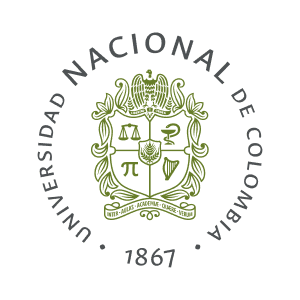

# Proyecto NLP

## Título:
Similitudes y Conexiones entre Papers

## Estudiantes:
- Angel David Pineros Sierra
- Miller Estiven Barrera Gonzalez
- Juan David Rodriguez Gomez
- Fabio Esteban Murcia Martínez

## Repositorio del Proyecto:
[https://github.com/mbarrerag/NLP-Dataset.git](https://github.com/mbarrerag/NLP-Dataset.git)

In [23]:
import pandas as pd
import os

# Clone the GitHub repository
!git clone https://github.com/mbarrerag/NLP-Dataset.git

fatal: destination path 'NLP-Dataset' already exists and is not an empty directory.


In [24]:
import re, json, html, unicodedata
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display


In [25]:
# Define necessary variables for the cleaning process
from pathlib import Path

DATASET_NAME = 'HORUS_Bogota_Ingenieria.xlsx'
DATASET_CANDIDATES = [
    Path('data/raw') / DATASET_NAME,
    Path('NLP-Dataset/data/raw') / DATASET_NAME,
    Path('NLP-Dataset') / DATASET_NAME,
]
dataset_path = next((path for path in DATASET_CANDIDATES if path.is_file()), DATASET_CANDIDATES[0])
if not dataset_path.is_file():
    raise FileNotFoundError(f'Dataset not found. Checked: {DATASET_CANDIDATES}')

SIMILARITY_METHOD = 'tfidf'
OUTPUT_DIR = 'output'
INPUT_FILE = dataset_path
SHEET_NAME = None

In [26]:
# Load the dataset using the configured file path and worksheet
sheet = 0 if SHEET_NAME is None else SHEET_NAME
df = pd.read_excel(INPUT_FILE, sheet_name=sheet)
print(f"Successfully loaded dataset from: {INPUT_FILE}")
display(df.head(10))

Successfully loaded dataset from: NLP-Dataset\HORUS_Bogota_Ingenieria.xlsx


,Título original,Descripción original,Revista / Conferencia,Coautores,Doi,ISBN,ISSN,Citaciones,Idioma,Fecha,Tipo,Fuente,Enlace
0,Post-harvest evaluation of the effect of folia...,NaN,Plant Signaling & Behavior,"Florez Roncancio Victor Julio, Darghan Contrer...",10.1080/15592324.2025.2465234,NaN,15592316,0.0,Inglés,31/12/2025,Artículo de revista,WEB OF SCIENCE,https://www.webofscience.com/wos/woscc/full-re...
1,Prebiotic potential of cocoa bean shells in fo...,NaN,Cogent Food & Agriculture,"Botina Azain Blanca Lucia, Montoya Campuzano O...",10.1080/23311932.2025.2536915,NaN,23311932,0.0,Inglés,31/12/2025,Artículo de revista,WEB OF SCIENCE,https://www.webofscience.com/wos/woscc/full-re...
2,Exploring microbial soil communities structure...,NaN,Cogent Food & Agriculture,"Saavedra Correa, Juan David, Aristizabal Gutie...",10.1080/23311932.2025.2548928,NaN,23311932,0.0,Inglés,31/12/2025,Artículo de revista,WEB OF SCIENCE,https://www.webofscience.com/wos/woscc/full-re...
3,Recent advances in solvent development for car...,"The practices of carbon capture, storage, and ...",Separation and Purification Technology,"Vargas Sáenz Julio Cesar, Castro Juan Jose, Qu...",10.1016/j.seppur.2025.134962,NaN,"13835866, 18733794",1.0,Inglés,31/12/2025,Estado del arte,SCOPUS,https://www.scopus.com/inward/record.uri?partn...
4,Effect of the conformation of a diazoted-resor...,"In the present work, a mono-diazoted resorcin[...",Journal of Molecular Structure,"Maldonado Villamil Mauricio, López Mónica, Est...",10.1016/j.molstruc.2025.143311,NaN,00222860,0.0,Inglés,15/12/2025,Artículo de revista,SCOPUS,https://www.scopus.com/inward/record.uri?partn...
5,Study of Tm3+ incorporation in TiO2 coatings f...,"In this work, the synthesis and characterizati...",Applied Surface Science,"Torres Ceron Darwin Augusto, Restrepo Parra El...",10.1016/j.apsusc.2025.164338,NaN,01694332,0.0,Inglés,15/12/2025,Artículo de revista,SCOPUS,https://www.scopus.com/inward/record.uri?partn...
6,Tuning confined states in Si1−xGex photonic ca...,"In this work, using the transfer matrix method...","Physica . B , Condensed Matter","Vinck Posada Herbert, Francis Segovia Chaves, ...",10.1016/j.physb.2025.417984,NaN,09214526,0.0,Inglés,15/12/2025,Artículo de revista,SCOPUS,https://dx.doi.org/10.1016/j.physb.2025.417984...
7,The NW-Amazonian Craton in Colombia: A Paleo-M...,The geological evolution of the NW-Amazonian C...,Journal of South American Earth Sciences,"Cramer Thomas Heinrich, Amed Bonilla, Hernánde...",10.1016/j.jsames.2025.105806,NaN,08959811,0.0,Inglés,15/12/2025,Estado del arte,SCOPUS,https://dx.doi.org/10.1016/j.jsames.2025.10580...
8,Scientometric analysis of computational calcul...,The rapid industrialization has driven economi...,Global Journal of Environmental Science and Ma...,"Torres Ceron Darwin Augusto, Restrepo Parra El...",10.22034/gjesm.2025.01.18,NaN,"23833866, 23833572",1.0,Inglés,01/12/2025,Artículo de revista,SCOPUS,https://dx.doi.org/10.22034/gjesm.2025.01.18 ...
9,Transition clinics in pediatric rheumatology i...,Introduction: Transition clinics are conceived...,Advances in Rheumatology,"Quintana López Gerardo, Ramirez Lauren Natalia...",10.1186/s42358-024-00419-2,NaN,25233106,0.0,Inglés,01/12/2025,Estado del arte,SCOPUS,https://www.scopus.com/inward/record.uri?partn...


#Columas del dataset

*   **`paper_id`**: Un identificador único generado para cada registro, comenzando con `HORUS_` seguido de un número secuencial.
*   **`title_normalized`**: Una versión normalizada del `Título original`, convertida a minúsculas y limpiada de caracteres especiales.
*   **`abstract_clean`**: Una versión limpia de la `Descripción original` (abstract), donde se eliminan etiquetas HTML y se normaliza el espacio en blanco.
*   **`abstract_status`**: Indica si el abstract está presente (`PRESENT`) o si falta (`MISSING_ABSTRACT`).
*   **`journal_normalized`**: Una versión limpia de la columna `Revista / Conferencia`.
*   **`doi_normalized`**: El DOI (Digital Object Identifier) de la publicación, extraído y normalizado para asegurar un formato consistente.
*   **`issn_normalized`**: El ISSN (International Standard Serial Number) de la publicación, extraído y normalizado.
*   **`language_iso639_1`** o **`idioma normalizado`**: El idioma de la publicación, mapeado a su código ISO 639-1 (ej., `en` para inglés, `es` para español). Si el idioma no se reconoce, se etiqueta como `und` (undetermined) o el texto original en mayúsculas.
*   **`document_type_normalized`**: El tipo de documento (ej., `JOURNAL_ARTICLE`, `CONFERENCE_PAPER`), normalizado a un conjunto de categorías predefinidas. Si no se reconoce, se etiqueta como `OTHER`.
*   **`source_normalized`**: La fuente de la publicación (ej., `WEB_OF_SCIENCE`, `SCOPUS`), normalizada a un conjunto de categorías predefinidas. Si no se reconoce, se etiqueta como `UNKNOWN`.
*   **`publication_date`**: La fecha de publicación, convertida al formato `YYYY-MM-DD`.
*   **`publication_year`**: El año de publicación, extraído de la fecha de publicación.
*   **`citations_normalized`**: El número de citaciones, convertido a formato numérico entero y con valores faltantes llenados con 0.
*   **`authors_normalized`**: Una lista de autores, donde los nombres se limpian y se separan adecuadamente.
*   **`authors_normalized_text`**: Una cadena de texto que concatena los autores normalizados, separados por ` | `.
*   **`text_for_nlp`**: Un campo combinado del título normalizado y el abstract limpio, diseñado para ser utilizado en tareas de procesamiento de lenguaje natural (NLP).
*   **`labels`**: Un diccionario que contiene etiquetas categóricas extraídas automáticamente (como `research_area`, `topics`, `methods`, `data_types`, `metrics`) para cada artículo, basado en la taxonomía definida.

## Valores nulos

In [27]:
# Contar los valores nulos iniciales en el DataFrame 'df' (el DataFrame original cargado)
print("Valores nulos por columna en el DataFrame inicial:")
display(df.isnull().sum())

Valores nulos por columna en el DataFrame inicial:


Título original              0
Descripción original      1478
Revista / Conferencia     6754
Coautores                    0
Doi                      13846
ISBN                     23331
ISSN                     13568
Citaciones                1496
Idioma                     180
Fecha                        0
Tipo                         0
Fuente                       0
Enlace                   10701
dtype: int64

## Posibles duplicados

In [28]:
# Encontrar y eliminar registros con el mismo 'Título original', 'Descripción original' y 'Fecha'
duplicate_subset = ['Título original', 'Descripción original', 'Fecha']
duplicate_mask = df.duplicated(subset=duplicate_subset, keep=False)
duplicate_titles_abstracts = df.loc[duplicate_mask].copy()

if not duplicate_titles_abstracts.empty:
    print(f"Se encontraron {len(duplicate_titles_abstracts)} registros que pertenecen a grupos duplicados:")
    display(duplicate_titles_abstracts.sort_values(by=duplicate_subset))
    rows_before = len(df)
    df = df.drop_duplicates(subset=duplicate_subset, keep='first').copy()
    print(f"Se eliminaron {rows_before - len(df)} duplicados; quedan {len(df)} registros.")
else:
    print("No se encontraron registros duplicados.")

Se encontraron 50 registros que pertenecen a grupos duplicados:


,Título original,Descripción original,Revista / Conferencia,Coautores,Doi,ISBN,ISSN,Citaciones,Idioma,Fecha,Tipo,Fuente,Enlace
21148,Colombia 2023: International Conference on Mar...,--,NaN,"Osorio Arias Andres Fernando, Ballantyne Puin ...",NaN,NaN,NaN,NaN,Inglés,01/01/2022,Proyecto,HERMES,NaN
21217,Colombia 2023: International Conference on Mar...,--,NaN,Zea Sjoberg Sven Eloy,NaN,NaN,NaN,NaN,Inglés,01/01/2022,Proyecto,HERMES,NaN
17430,EDITORIAL,NaN,Revista de la Facultad de Ciencias ( Medellín ...,"Lopez Rios Victor Ignacio, Montoya, José A.",NaN,NaN,"0121747X, 23575549",0.0,NaN,01/07/2022,Artículo de revista,RevistasUNAL,https://revistas.unal.edu.co/index.php/rfc/art...
17449,EDITORIAL,NaN,Revista de la Facultad de Ciencias ( Medellín ...,"Lopez Rios Victor Ignacio, Montoya, José A.",NaN,NaN,"0121747X, 23575549",0.0,NaN,01/07/2022,Editorial,SCOPUS,https://www.scopus.com/inward/record.uri?partn...
20379,Editorial,NaN,Revista Colombiana de Estadística,Giraldo Henao Ramon,NaN,NaN,"23898976, 01201751",0.0,Indonesio,01/01/2022,Artículo de revista,RevistasUNAL,https://revistas.unal.edu.co/index.php/estad/a...
20423,Editorial,NaN,Historelo Revista de História Regional y Local,Ramirez Bacca Renzo,10.15446/historelo.v14n29.98802,NaN,2145132X,0.0,Indonesio,01/01/2022,Editorial,SCOPUS,https://dx.doi.org/10.15446/historelo.v14n29.9...
20424,Editorial,NaN,Historelo Revista de História Regional y Local,Ramirez Bacca Renzo,10.15446/HISTORELO.V14N29.98802,NaN,2145132X,0.0,Indonesio,01/01/2022,Editorial,SCOPUS,https://www.scopus.com/inward/record.uri?partn...
20556,Editorial,NaN,Revista Innovar Journal,Castañeda Rodriguez Victor Mauricio,10.15446/INNOVAR.V32N83.100245,NaN,"01215051, 22486968",0.0,Indonesio,01/01/2022,Editorial,SCOPUS,https://dx.doi.org/10.15446/INNOVAR.V32N83.100...
13063,Editorial,NaN,Historelo Revista de História Regional y Local,Ramirez Bacca Renzo,10.15446/historelo,NaN,2145132X,0.0,Indonesio,01/01/2023,Editorial,SCOPUS,https://www.scopus.com/inward/record.uri?partn...
13181,Editorial,NaN,Revista Innovar Journal,Castañeda Rodriguez Victor Mauricio,10.15446/innovar.v33n88.108077,NaN,"01215051, 22486968",0.0,Indonesio,01/01/2023,Editorial,SCOPUS,https://dx.doi.org/10.15446/innovar.v33n88.108...


Se eliminaron 28 duplicados; quedan 24972 registros.


## 1. Limpieza bibliográfica

Conservamos las columnas originales y añadimos campos normalizados. Los abstracts vacíos se marcan; nunca se inventa contenido.

In [29]:
Path(OUTPUT_DIR).mkdir(exist_ok=True)

def clean_text(x, lower=False):
    if pd.isna(x): return ''
    x = re.sub(r'<[^>]+>', ' ', html.unescape(str(x)))
    x = re.sub(r'\s+', ' ', unicodedata.normalize('NFKC', x)).strip()
    return x.lower() if lower else x
def norm_doi(x):
    x = re.sub(r'^(https?://(dx\.)?doi\.org/|doi:\s*)', '', clean_text(x, True))
    m = re.search(r'10\.\d{4,9}/[-._;()/:a-z0-9]+', x)
    return m.group(0).rstrip('.,;)') if m else ''
def norm_issn(x):
    d = re.sub(r'[^0-9Xx]', '', clean_text(x).replace('.0','')).upper()
    return f'{d[:4]}-{d[4:]}' if len(d) == 8 else clean_text(x)
LANG={'inglés':'en','ingles':'en','english':'en','español':'es','espanol':'es','spanish':'es','portugués':'pt','portugues':'pt','portuguese':'pt','francés':'fr','frances':'fr','french':'fr','alemán':'de','aleman':'de','german':'de','italiano':'it','catalán':'ca','galicia':'gl','vasco':'eu','indonesio':'id'}
TYPE={'artículo de revista':'JOURNAL_ARTICLE','articulo de revista':'JOURNAL_ARTICLE','artículo de conferencia':'CONFERENCE_PAPER','articulo de conferencia':'CONFERENCE_PAPER','ponencias en eventos especializados':'CONFERENCE_PRESENTATION','capítulo de libro':'BOOK_CHAPTER','capitulo de libro':'BOOK_CHAPTER','libro':'BOOK','tesis maestría':'MASTER_THESIS','tesis doctorado':'DOCTORAL_THESIS','tesis especialización':'SPECIALIZATION_THESIS','estado del arte':'LITERATURE_REVIEW','preimpresión':'PREPRINT','preimpresion':'PREPRINT','patente':'PATENT','proyecto':'PROJECT','editorial':'EDITORIAL','formato audiovisual':'AUDIOVISUAL'}
SOURCE={'web of science':'WEB_OF_SCIENCE','wos':'WEB_OF_SCIENCE','scopus':'SCOPUS','pubmed':'PUBMED','scielo':'SCIELO','repositoriounal':'REPOSITORIO_UNAL','revistasunal':'REVISTAS_UNAL','bibliotecasunal':'BIBLIOTECAS_UNAL','sara':'SARA','hermes':'HERMES'}
def norm_map(x, mapping, empty):
    k=clean_text(x,True); return mapping.get(k, empty if not k else k.upper().replace(' ','_'))
def parse_authors(x):
    raw=clean_text(x)
    if not raw:return []
    parts=[clean_text(a) for a in (raw.split(';') if ';' in raw else raw.split(','))] # Changed to handle multiple delimiters
    out=[];i=0
    while i<len(parts):
        a=parts[i]
        if a and len(a.split())==1 and i+1<len(parts): a=f'{a}, {parts[i+1]}';i+=1
        if a:out.append(a)
        i+=1
    return out

raw = df.copy()
expected={'Título original','Descripción original','Revista / Conferencia','Coautores','Doi','ISSN','Citaciones','Idioma','Fecha','Tipo','Fuente','Enlace'}
if missing:=expected-set(raw.columns):raise ValueError(f'Faltan: {sorted(missing)}')
papers=raw.copy();papers.insert(0,'paper_id',[f'HORUS_{i:06d}' for i in range(1,len(papers)+1)])

# Eliminar la columna 'Doi ISBN'
papers = papers.drop(columns=['Doi ISBN'], errors='ignore')
# Eliminar la columna 'ISBN'
papers = papers.drop(columns=['ISBN'], errors='ignore')

papers['title_normalized']=papers['Título original'].map(lambda x:clean_text(x,True));papers['abstract_clean']=papers['Descripción original'].map(clean_text)
papers['abstract_status']=np.where(papers.abstract_clean.eq(''),'MISSING_ABSTRACT','PRESENT');papers['journal_normalized']=papers['Revista / Conferencia'].map(clean_text)
papers['doi_normalized']=papers.Doi.map(norm_doi);papers['issn_normalized']=papers.ISSN.map(norm_issn);papers['language_iso639_1']=papers.Idioma.map(lambda x:LANG.get(clean_text(x,True),'und' if not clean_text(x,True) else clean_text(x,True)))
# Eliminar la columna 'Idioma' después de haberla usado para crear 'language_iso639_1'
papers = papers.drop(columns=['Idioma'], errors='ignore')
papers['document_type_normalized']=papers.Tipo.map(lambda x:norm_map(x,TYPE,'OTHER'));papers['source_normalized']=papers.Fuente.map(lambda x:norm_map(x,SOURCE,'UNKNOWN'))
date=pd.to_datetime(papers.Fecha,dayfirst=True,errors='coerce');papers['publication_date']=date.dt.strftime('%Y-%m-%d').fillna('');papers['publication_year']=date.dt.year.astype('Int64')
papers['citations_normalized']=pd.to_numeric(papers.Citaciones,errors='coerce').fillna(0).astype(int);papers['authors_normalized']=papers.Coautores.map(parse_authors);papers['authors_normalized_text']=papers.authors_normalized.map(' | '.join)
papers['text_for_nlp']=(papers.title_normalized+'. '+papers.abstract_clean.map(lambda x:clean_text(x,True))).str.strip('. ')
papers['dedup_key']=np.where(papers.doi_normalized.ne(''),'DOI:'+papers.doi_normalized,'TITLE_YEAR:'+papers.title_normalized+'|'+papers.publication_year.astype(str));papers['duplicate_group']=papers.groupby('dedup_key',sort=False).ngroup().map(lambda x:f'DUP_{x:06d}');papers['is_duplicate']=papers.duplicated('dedup_key',keep='first')
print(f'Registros: {len(papers):,} | Sin resumen: {papers.abstract_status.eq("MISSING_ABSTRACT").sum():,} | Duplicados: {papers.is_duplicate.sum():,}')
# Eliminar la columna 'is_duplicate' después de su uso en el print
papers = papers.drop(columns=['is_duplicate'], errors='ignore')
# Eliminar las columnas 'dedup_key' y 'duplicate_group' según la solicitud del usuario
papers = papers.drop(columns=['dedup_key', 'duplicate_group'], errors='ignore')
display(papers[['paper_id','Título original','doi_normalized','language_iso639_1','document_type_normalized','abstract_status']].head())

Registros: 24,972 | Sin resumen: 1,461 | Duplicados: 706


,paper_id,Título original,doi_normalized,language_iso639_1,document_type_normalized,abstract_status
0,HORUS_000001,Post-harvest evaluation of the effect of folia...,10.1080/15592324.2025.2465234,en,JOURNAL_ARTICLE,MISSING_ABSTRACT
1,HORUS_000002,Prebiotic potential of cocoa bean shells in fo...,10.1080/23311932.2025.2536915,en,JOURNAL_ARTICLE,MISSING_ABSTRACT
2,HORUS_000003,Exploring microbial soil communities structure...,10.1080/23311932.2025.2548928,en,JOURNAL_ARTICLE,MISSING_ABSTRACT
3,HORUS_000004,Recent advances in solvent development for car...,10.1016/j.seppur.2025.134962,en,LITERATURE_REVIEW,PRESENT
4,HORUS_000005,Effect of the conformation of a diazoted-resor...,10.1016/j.molstruc.2025.143311,en,JOURNAL_ARTICLE,PRESENT


## 4. Taxonomía de etiquetas y extracción con evidencia

La taxonomía es controlada y editable. Cada detección guarda: etiqueta canónica, variante encontrada, texto de evidencia, regla y confianza. Las etiquetas producidas aquí son **automáticas y verificables**, no etiquetas humanas validadas.

In [30]:
# Diccionario controlado inicial. Amplíalo con términos propios de las facultades de la UNAL.
TAXONOMY = {
    "research_area": {
        "COMPUTER_SCIENCE": ["computer science", "ciencias de la computación", "informática", "informatics"],
        "ENGINEERING": ["engineering", "ingeniería", "ingenieria"],
        "AGRICULTURE": ["agriculture", "agricultura", "crop", "cultivo", "plant", "planta"],
        "HEALTH_SCIENCES": ["medicine", "medical", "health", "salud", "clinical", "clínic"],
        "ENVIRONMENTAL_SCIENCE": ["environment", "environmental", "ambiental", "climate", "clima"],
        "SOCIAL_SCIENCES": ["social science", "ciencias sociales", "education", "educación"]
    },
    "topics": {
        "MACHINE_LEARNING": ["machine learning", "aprendizaje automático", "aprendizaje automatico", "ml"],
        "ARTIFICIAL_INTELLIGENCE": ["artificial intelligence", "inteligencia artificial", "ai"],
        "CLIMATE_CHANGE": ["climate change", "cambio climático", "cambio climatico"],
        "SUSTAINABILITY": ["sustainability", "sostenibilidad", "sustainable", "sostenible"],
        "PUBLIC_HEALTH": ["public health", "salud pública", "salud publica"]
    },
    "methods": {
        "RANDOM_FOREST": ["random forest", "bosque aleatorio"],
        "SUPPORT_VECTOR_MACHINE": ["support vector machine", "support vector machines", "svm"],
        "NEURAL_NETWORK": ["neural network", "neural networks", "red neuronal", "redes neuronales"],
        "CONVOLUTIONAL_NEURAL_NETWORK": ["convolutional neural network", "cnn"],
        "PRINCIPAL_COMPONENT_ANALYSIS": ["principal component analysis", "pca", "análisis de componentes principales", "analisis de componentes principales"],
        "SYSTEMATIC_REVIEW": ["systematic review", "revisión sistemática", "revision sistematica"],
        "EXPERIMENTAL_STUDY": ["experimental study", "estudio experimental"]
    },
    "data_types": {
        "TIME_SERIES": ["time series", "series de tiempo", "serie temporal"],
        "SATELLITE_IMAGES": ["satellite image", "satellite images", "imagen satelital", "imágenes satelitales"],
        "SURVEY_DATA": ["survey", "encuesta", "questionnaire", "cuestionario"],
        "CLINICAL_DATA": ["clinical data", "datos clínicos", "datos clinicos"]
    },
    "metrics": {
        "ACCURACY": ["accuracy", "exactitud"],
        "PRECISION": ["precision", "precisión"],
        "RECALL": ["recall", "sensibilidad"],
        "F1_SCORE": ["f1-score", "f1 score", "f1"]
    }
}

def phrase_pattern(term):
    # Evita que "ai" se detecte dentro de palabras como "rain".
    return re.compile(r"(?<!\w)" + re.escape(term.lower()) + r"(?!\w)", flags=re.IGNORECASE)

def extract_labels(row):
    text = row["text_for_nlp"]
    findings = []
    for category, labels in TAXONOMY.items():
        for canonical, aliases in labels.items():
            for alias in aliases:
                match = phrase_pattern(alias).search(text)
                if match:
                    start, end = max(0, match.start() - 80), min(len(text), match.end() + 80)
                    findings.append({
                        "paper_id": row["paper_id"],
                        "category": category,
                        "label_canonical": canonical,
                        "label_original": alias,
                        "evidence_text": text[start:end],
                        "extraction_method": "RULE_BASED_TAXONOMY",
                        "confidence": 1.0,
                        "validation_status": "AUTO_EXTRACTED"
                    })
                    break
    return findings

label_rows = []
for _, paper in papers.iterrows():
    label_rows.extend(extract_labels(paper))
labels = pd.DataFrame(label_rows, columns=[
    "paper_id", "category", "label_canonical", "label_original", "evidence_text",
    "extraction_method", "confidence", "validation_status"
]).drop_duplicates(["paper_id", "category", "label_canonical"])

# Etiquetas por paper, útiles para RAG/KAG y export JSON.
labels_by_paper = (labels.groupby(["paper_id", "category"])["label_canonical"]
                   .apply(list).unstack(fill_value=[]).to_dict(orient="index")) if not labels.empty else {}
papers["labels"] = papers["paper_id"].map(lambda pid: labels_by_paper.get(pid, {}))

print(f"Etiquetas automáticas extraídas: {len(labels):,}")
display(labels.head(10))

Etiquetas automáticas extraídas: 16,459


,paper_id,category,label_canonical,label_original,evidence_text,extraction_method,confidence,validation_status
0,HORUS_000009,research_area,ENVIRONMENTAL_SCIENCE,environmental,"ven economic growth and population increase, b...",RULE_BASED_TAXONOMY,1.0,AUTO_EXTRACTED
1,HORUS_000009,topics,SUSTAINABILITY,sustainable,"e research and innovation, thereby playing a c...",RULE_BASED_TAXONOMY,1.0,AUTO_EXTRACTED
2,HORUS_000010,research_area,HEALTH_SCIENCES,medical,"ted to the active, multidimensional developmen...",RULE_BASED_TAXONOMY,1.0,AUTO_EXTRACTED
3,HORUS_000010,research_area,ENVIRONMENTAL_SCIENCE,environment,"emotional, and social dimensions of each patie...",RULE_BASED_TAXONOMY,1.0,AUTO_EXTRACTED
4,HORUS_000011,research_area,HEALTH_SCIENCES,clinical,sion curve analysis revealed a net benefit in ...,RULE_BASED_TAXONOMY,1.0,AUTO_EXTRACTED
5,HORUS_000013,research_area,ENVIRONMENTAL_SCIENCE,environmental,"nd disposal, being directly related to traffic...",RULE_BASED_TAXONOMY,1.0,AUTO_EXTRACTED
6,HORUS_000013,topics,SUSTAINABILITY,sustainable,"face of uncertainty, is emphasized. the system...",RULE_BASED_TAXONOMY,1.0,AUTO_EXTRACTED
7,HORUS_000013,methods,NEURAL_NETWORK,neural networks,wed including future prediction and optimizati...,RULE_BASED_TAXONOMY,1.0,AUTO_EXTRACTED
8,HORUS_000013,methods,SYSTEMATIC_REVIEW,systematic review,"efficiency, despite limitations in the face o...",RULE_BASED_TAXONOMY,1.0,AUTO_EXTRACTED
9,HORUS_000017,topics,ARTIFICIAL_INTELLIGENCE,artificial intelligence,ntifies significant themes for the future rese...,RULE_BASED_TAXONOMY,1.0,AUTO_EXTRACTED


### 5. Generación de relaciones y similitudes (inicialización placeholder)


In [31]:

# Inicializar relations_df y similarities como DataFrames vacíos si no han sido definidos
# Esto es un placeholder; se espera que estas variables se llenen con datos reales
# en pasos posteriores del análisis.
# Por ejemplo, relations_df podría tener columnas como ['source_paper_id', 'target_paper_id', 'relation_type', 'weight']
# y similarities podría tener ['paper_id_1', 'paper_id_2', 'similarity_score']

if 'relations_df' not in locals():
    relations_df = pd.DataFrame(columns=['source_paper_id', 'target_paper_id', 'relation_type', 'weight'])
    print("relations_df inicializado como DataFrame vacío.")

if 'similarities' not in locals():
    similarities = pd.DataFrame(columns=['paper_id_1', 'paper_id_2', 'similarity_score'])
    print("similarities inicializado como DataFrame vacío.")

relations_df inicializado como DataFrame vacío.
similarities inicializado como DataFrame vacío.


In [ ]:
import shutil
from pathlib import Path

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

if 'labels' not in papers.columns:
    if 'labels' in locals() and not labels.empty:
        labels_by_paper_recomputed = (labels.groupby(["paper_id", "category"])["label_canonical"]
                                      .apply(list).unstack(fill_value={}).to_dict(orient="index"))
    else:
        labels_by_paper_recomputed = {}
    papers["labels"] = papers["paper_id"].map(lambda pid: labels_by_paper_recomputed.get(pid, {}))
    print("La columna 'labels' ha sido añadida/recreada en el DataFrame 'papers' para la exportación.")

papers_export = papers.copy()

if 'Idioma' in papers_export.columns:
    papers_export = papers_export.drop(columns=['Idioma'])
if 'language_iso639_1' in papers_export.columns:
    papers_export = papers_export.rename(columns={'language_iso639_1': 'idioma normalizado'})

if 'labels' in papers_export.columns:
    papers_export['labels'] = papers_export['labels'].apply(lambda x: json.dumps(x, ensure_ascii=False) if isinstance(x, dict) else '{}')
else:
    print("Advertencia: La columna 'labels' no se encontró en papers_export. Se creará una columna con diccionarios vacíos para la exportación.")
    papers_export['labels'] = pd.Series(['{}'] * len(papers_export), index=papers_export.index)

papers_export.to_csv(f"{OUTPUT_DIR}/papers_clean.csv", index=False, encoding="utf-8-sig")

with open(f"{OUTPUT_DIR}/taxonomy.json", "w", encoding="utf-8") as f:
    json.dump(TAXONOMY, f, ensure_ascii=False, indent=2)

paper_entities = []
for _, p in papers.iterrows():
    paper_entities.append({
        "paper_id": p.paper_id,
        "doi": p.doi_normalized or None,
        "title_original": p["Título original"],
        "title_normalized": p.title_normalized,
        "abstract_status": p.abstract_status,
        "idioma_normalizado": p.language_iso639_1,
        "publication_year": None if pd.isna(p.publication_year) else int(p.publication_year),
        "document_type": p.document_type_normalized,
        "authors": p.authors_normalized,
        "labels": p.labels
    })
with open(f"{OUTPUT_DIR}/paper_entities.json", "w", encoding="utf-8") as f:
    json.dump(paper_entities, f, ensure_ascii=False, indent=2)
with open(f"{OUTPUT_DIR}/paper_relations.json", "w", encoding="utf-8") as f:
    json.dump(relations_df.to_dict(orient="records"), f, ensure_ascii=False, indent=2)

labels.to_csv(f"{OUTPUT_DIR}/label_traceability.csv", index=False, encoding="utf-8-sig")
similarities.to_csv(f"{OUTPUT_DIR}/similarity_candidates.csv", index=False, encoding="utf-8-sig")

quality = pd.DataFrame([
    {"metric": "total_records", "value": len(papers)},
    {"metric": "missing_abstract", "value": int(papers.abstract_status.eq("MISSING_ABSTRACT").sum())},
    {"metric": "missing_doi", "value": int(papers.doi_normalized.eq("").sum())},
    {"metric": "unknown_language", "value": int(papers.language_iso639_1.eq("und").sum())},
    {"metric": "auto_extracted_labels", "value": len(labels)},
    {"metric": "graph_relations", "value": len(relations_df)},
    {"metric": "similarity_pairs", "value": len(similarities)}
])
quality.to_csv(f"{OUTPUT_DIR}/data_quality_report.csv", index=False, encoding="utf-8-sig")

archive = shutil.make_archive("HORUS_estandarizado", "zip", OUTPUT_DIR)
print(f"Listo. Archivo generado: {Path(archive).resolve()}")

display(papers.head())